# Sewa Jas & Formal Wear — Training Pipeline (IndoBERT Fine-tuning)

Versi ini **fine-tune IndoBERT langsung** ke data intent kamu (bukan cuma dipakai sebagai
embedding statis seperti percobaan sentence-transformer sebelumnya, yang malah menurunkan
akurasi dari 89.8% -> 83.4%). Fine-tuning membuat modelnya benar-benar belajar pola
kalimat gaul/singkatan khas data kamu ("min", "gak", "kudu", dst), bukan cuma pakai makna
umum dari model generik.

**Kenapa ini beda dari percobaan sebelumnya:**
- Sebelumnya: `sentence-transformer` dipakai apa adanya (zero-shot) untuk menghasilkan
  vektor, lalu SVM dilatih di atas vektor itu. Model embedding-nya sendiri **tidak pernah
  melihat data kamu**.
- Sekarang: bobot IndoBERT (`indobenchmark/indobert-base-p1`) di-**fine-tune** (dilatih ulang)
  langsung ke ~1800+ pattern kamu, jadi representasi yang dipelajari memang spesifik ke
  domain sewa jas & gaya bahasa chat kamu.

**Trade-off yang perlu kamu tau:**
- Butuh GPU (Colab: Runtime -> Change runtime type -> GPU) supaya training gak lambat.
- Waktu training jauh lebih lama dari TF-IDF+SVM (menit, bukan detik).
- Dengan data sekecil ini (~1800-3600 pattern setelah augmentasi), ada risiko overfitting --
  makanya di notebook ini dipakai learning rate kecil, epoch dibatasi, dan early-stopping
  berdasarkan macro-F1 di validation set.
- **Saya tidak bisa menjalankan notebook ini sendiri** karena data (`intents.json`,
  `knowledge_base.json`) dan modul pendukung (`entity_extractor`, `text_processor`,
  `augment_data`, dll) ada di Google Drive kamu, bukan ikut ter-upload. Jalankan sendiri di
  Colab lalu kirim classification report + confusion matrix barunya lagi ke saya.

**PENTING:** pastikan kamu pakai `intents_fixed.json` (hasil perbaikan data sebelumnya) sebagai
sumber `intents.json`, bukan file lama -- ganti path di sel 2, atau replace langsung filenya.

**Struktur folder** mengikuti pola project asli: `data/raw`, `data/knowledge`, `src/jas_chatbot/`, `scripts/`, `models/`.

In [43]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Imports

In [44]:
!pip uninstall -y torch torchvision torchaudio -q
!pip install torch torchvision torchaudio -q

In [45]:
import sys
import random
import json
import pickle
import collections
from pathlib import Path
from datetime import date

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset

import transformers
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback,
)

import sklearn
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix,
    precision_recall_fscore_support,
)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "/content/drive/MyDrive/v4/jas-chatbot/src"))
sys.path.insert(0, str(ROOT / "/content/drive/MyDrive/v4/jas-chatbot/scripts"))

from jas_chatbot.nlu.entity_extractor import EntityExtractor
from jas_chatbot.nlu.intent_classifier import GREETING_INTENTS
from augment_data import augment_pattern
# TextProcessor (stemmer) SENGAJA TIDAK dipakai di versi ini -- IndoBERT punya
# tokenizer & subword embedding sendiri yang sudah menangani imbuhan Bahasa
# Indonesia, jadi stemming manual justru bisa membuang informasi.

sns.set_style("whitegrid")
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
RANDOM_STATE = 42

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("torch", torch.__version__, "| transformers", transformers.__version__, "| device:", DEVICE)
if DEVICE == "cpu":
    print("PERINGATAN: tidak ada GPU terdeteksi. Runtime -> Change runtime type -> GPU, "
          "kalau tidak, fine-tuning bisa sangat lambat.")

MODEL_NAME = "indobenchmark/indobert-base-p1"
# alternatif kalau model ini gagal didownload/error: "indolem/indobert-base-uncased"


torch 2.13.0+cu130 | transformers 5.13.1 | device: cuda


## 2. Build the knowledge-derived files

Sama seperti pipeline TF-IDF sebelumnya: `intents.json` (skema `intent`/`contoh_pertanyaan`)
dikonversi ke skema `tag`/`patterns`, dan `entities_katalog.json` dibangun dari
`knowledge_base.json` untuk dipakai `EntityExtractor` (placeholder ukuran & warna).

**Pastikan `intents.json` di path bawah ini sudah versi yang sudah diperbaiki (`intents_fixed.json`).**

In [46]:
import re as _re

with open(ROOT / "/content/drive/MyDrive/v4/jas-chatbot/data/raw/intents.json", encoding="utf-8") as f:
    _raw = json.load(f)

semantic = {"intents": []}
for it in _raw["intents"]:
    semantic["intents"].append({
        "tag": it["intent"],
        "patterns": it["contoh_pertanyaan"],
        "jawaban_default": it.get("jawaban_default"),
        "context_set": it.get("context_set"),
    })
with open(ROOT / "/content/drive/MyDrive/v4/jas-chatbot/data/raw/intents_semantic.json", "w", encoding="utf-8") as f:
    json.dump(semantic, f, ensure_ascii=False, indent=2)

with open(ROOT / "/content/drive/MyDrive/v4/jas-chatbot/data/knowledge/knowledge_base.json", encoding="utf-8") as f:
    kb = json.load(f)

colors, sizes = set(), set()
models_by_jenis = collections.defaultdict(set)

def collect_varian_warna(varian_warna_list):
    for v in varian_warna_list:
        colors.add(v["warna"])
        for u in v.get("ukuran_tersedia", []):
            sizes.add(str(u))

for jenis, cat in kb["produk"].items():
    if "varian_model" in cat:
        # struktur baru: tiap model punya varian_warna sendiri (jas, celana)
        for vm in cat["varian_model"]:
            models_by_jenis[jenis].add(vm["model"])
            collect_varian_warna(vm.get("varian_warna", []))
    else:
        # struktur lama/flat, mis. sepatu (belum ada dimensi model)
        collect_varian_warna(cat.get("varian_warna", []))

expanded = set(colors)
for w in list(colors):
    m = _re.match(r"^(.*)\s*\(([^)]+)\)\s*$", w)
    if m:
        expanded.add(m.group(1).strip())
        expanded.add(m.group(2).strip())

entities = {
    "warna": sorted(expanded, key=len, reverse=True),
    "ukuran": sorted(sizes, key=len, reverse=True),
}
for jenis, models in models_by_jenis.items():
    entities[f"model_{jenis}"] = sorted(models, key=len, reverse=True)

with open(ROOT / "/content/drive/MyDrive/v4/jas-chatbot/data/knowledge/entities_katalog.json", "w", encoding="utf-8") as f:
    json.dump(entities, f, ensure_ascii=False, indent=2)

print(f"Tags: {len(semantic['intents'])}, total patterns: {sum(len(i['patterns']) for i in semantic['intents'])}")
print(f"Warna terdeteksi: {entities['warna']}")
print(f"Jumlah nilai ukuran unik: {len(entities['ukuran'])}")
for jenis, models in models_by_jenis.items():
    print(f"Model {jenis}: {sorted(models)}")

Tags: 20, total patterns: 2158
Warna terdeteksi: ['Biru Dongker (Navy)', 'Biru Elektrik', 'Abu-abu Muda', 'Putih Tulang', 'Biru Dongker', 'Abu-abu Tua', 'Hijau Army', 'Coklat Tua', 'Biru Muda', 'Silver', 'Maroon', 'Cream', 'Hitam', 'Navy']
Jumlah nilai ukuran unik: 29
Model jas: ['3-Piece (dengan Vest/Rompi)', 'Casual/Semi Formal', 'Double Breasted', 'Formal Klasik', 'Regular Fit', 'Single Breasted', 'Slim Fit']
Model celana: ['Regular Fit', 'Slim Fit', 'Straight Fit']


## 3. Load patterns & labels

In [47]:
with open(ROOT / "/content/drive/MyDrive/v4/jas-chatbot/data/raw/intents_semantic.json", encoding="utf-8") as f:
    data = json.load(f)

patterns, labels = [], []
for intent in data["intents"]:
    for p in intent["patterns"]:
        patterns.append(p)
        labels.append(intent["tag"])

print(f"Total patterns: {len(patterns)}")
print(f"Classes ({len(set(labels))}):")
for tag, n in collections.Counter(labels).most_common():
    print(f"  {tag:24} {n}")


Total patterns: 2158
Classes (20):
  cara_sewa                206
  tanya_ukuran             199
  tanya_stok_barang        125
  tidak_dikenali           118
  tanya_warna_sepatu       115
  denda_keterlambatan      115
  tanya_harga              113
  tanya_lokasi_dan_jam     113
  reschedule_pembatalan    102
  tanya_ukuran_celana      100
  tanya_ukuran_sepatu      100
  tanya_warna_jas          100
  tanya_warna_celana       100
  tanya_durasi_sewa        100
  cara_bayar               98
  sapaan                   91
  ucapan_terima_kasih      81
  layanan_antar            73
  promo_diskon             70
  tanya_model              39


## 4. Preprocessing (entity placeholder only, no stemming)

Sama seperti versi sentence-transformer: warna/ukuran diganti placeholder biar model
generalisasi ("jas warna hitam" & "jas warna navy" jadi pola yang sama), tapi TANPA
stemming/stopword-removal -- IndoBERT bekerja lebih baik dengan teks natural.

In [48]:
extractor = EntityExtractor(ROOT / "/content/drive/MyDrive/v4/jas-chatbot/data/knowledge/entities_katalog.json")

def preprocess_for_bert(raw: str) -> str:
    neutral = extractor.replace_with_placeholder(raw)
    return neutral.lower().strip()

for example in ["ada jas ukuran L?", "celana warna navy ada size 32 gak", "selamat pagi min"]:
    print(f"{example!r:42} -> {preprocess_for_bert(example)!r}")


'ada jas ukuran L?'                        -> 'ada jas ukuran [ukuran]?'
'celana warna navy ada size 32 gak'        -> 'celana warna [warna] ada size [ukuran] gak'
'selamat pagi min'                         -> 'selamat pagi min'


## 5. Train/test split

In [49]:
p_train, p_test, y_train_lbl, y_test_lbl = train_test_split(
    patterns, labels, test_size=0.2, random_state=RANDOM_STATE, stratify=labels,
)
print(f"Train (pre-aug): {len(p_train)}   Test: {len(p_test)}")


Train (pre-aug): 1726   Test: 432


## 6. Augmentation + tokenisasi

Augmentasi pattern lama (`augment_data.augment_pattern`) tetap dipakai supaya kelas kecil
(`layanan_antar`, `promo_diskon`, `ucapan_terima_kasih` yang cuma 8 sampel) dapat variasi
lebih banyak sebelum fine-tuning -- BERT lebih rakus data dibanding TF-IDF+SVM.

In [50]:
aug_patterns, aug_labels = [], []
for pattern, label in zip(p_train, y_train_lbl):
    for variant in augment_pattern(pattern, label):
        aug_patterns.append(variant)
        aug_labels.append(label)

print(f"Train after augmentation: {len(aug_patterns)} "
      f"(x{len(aug_patterns)/len(p_train):.1f})")

X_train_text = [preprocess_for_bert(p) for p in aug_patterns]
X_test_text  = [preprocess_for_bert(p) for p in p_test]

label_encoder = LabelEncoder().fit(aug_labels + y_test_lbl)
y_train = label_encoder.transform(aug_labels)
y_test  = label_encoder.transform(y_test_lbl)
N_CLASSES = len(label_encoder.classes_)
print("Jumlah kelas:", N_CLASSES)


Train after augmentation: 5453 (x3.2)
Jumlah kelas: 20


In [51]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

MAX_LEN = 48  # pattern kamu pendek-pendek (kalimat chat), 48 token subword lebih dari cukup

class IntentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=MAX_LEN):
        self.enc = tokenizer(
            texts, truncation=True, padding="max_length", max_length=max_len,
            return_tensors="pt",
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.enc.items()}
        item["labels"] = self.labels[idx]
        return item

train_dataset = IntentDataset(X_train_text, y_train, tokenizer)
test_dataset  = IntentDataset(X_test_text,  y_test,  tokenizer)
print(f"Train dataset: {len(train_dataset)}  |  Test dataset: {len(test_dataset)}")


Train dataset: 5453  |  Test dataset: 432


## 7. Load IndoBERT + custom Trainer (weighted loss)

Kelas imbalanced (support 8 vs 40), jadi loss di-weight per kelas (analog `class_weight="balanced"`
di sklearn) supaya kelas kecil gak diabaikan model.

In [52]:
class_weights = compute_class_weight(
    class_weight="balanced", classes=np.arange(N_CLASSES), y=y_train,
)
class_weights_t = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)
print("Class weights (balanced):")
for cls, w in zip(label_encoder.classes_, class_weights):
    print(f"  {cls:24} {w:.3f}")

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=N_CLASSES,
).to(DEVICE)


class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = nn.CrossEntropyLoss(weight=class_weights_t)
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss


[transformers] You passed `num_labels=20` which is incompatible to the `id2label` map of length `5`.


Class weights (balanced):
  cara_bayar               1.053
  cara_sewa                0.498
  denda_keterlambatan      0.903
  layanan_antar            1.458
  promo_diskon             1.558
  reschedule_pembatalan    1.014
  sapaan                   1.324
  tanya_durasi_sewa        1.113
  tanya_harga              0.927
  tanya_lokasi_dan_jam     0.963
  tanya_model              2.932
  tanya_stok_barang        0.795
  tanya_ukuran             0.504
  tanya_ukuran_celana      1.029
  tanya_ukuran_sepatu      1.057
  tanya_warna_celana       1.049
  tanya_warna_jas          1.037
  tanya_warna_sepatu       0.963
  tidak_dikenali           1.482
  ucapan_terima_kasih      1.391


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [53]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    macro_f1 = f1_score(labels, preds, average="macro", zero_division=0)
    return {"accuracy": acc, "macro_f1": macro_f1}

training_args = TrainingArguments(
    output_dir=str(ROOT / "models" / "indobert_checkpoints"),
    num_train_epochs=8,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    logging_steps=50,
    report_to="none",
    seed=RANDOM_STATE,
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

trainer.train()


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.550045,0.467581,0.895833,0.890095
2,0.073001,0.284867,0.942130,0.942767
3,0.027297,0.344777,0.942130,0.937539
4,0.009275,0.382615,0.949074,0.945544
5,0.002404,0.372232,0.949074,0.945703
6,0.001857,0.391140,0.946759,0.943285
7,0.001659,0.393578,0.951389,0.947777
8,0.001473,0.398347,0.949074,0.946026


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2728, training_loss=0.22360071864339612, metrics={'train_runtime': 557.9054, 'train_samples_per_second': 78.192, 'train_steps_per_second': 4.89, 'total_flos': 1076232345560064.0, 'train_loss': 0.22360071864339612, 'epoch': 8.0})

## 8. Evaluasi di held-out test set

In [54]:
pred_output = trainer.predict(test_dataset)
y_pred = np.argmax(pred_output.predictions, axis=-1)

acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
print(f"Held-out test accuracy: {acc*100:.2f}%")
print(f"Macro F1-score:         {macro_f1*100:.2f}%")


Held-out test accuracy: 95.14%
Macro F1-score:         94.78%


In [55]:
print(classification_report(
    y_test, y_pred, target_names=label_encoder.classes_,
    digits=3, zero_division=0,
))


                       precision    recall  f1-score   support

           cara_bayar      1.000     1.000     1.000        20
            cara_sewa      0.975     0.951     0.963        41
  denda_keterlambatan      0.913     0.913     0.913        23
        layanan_antar      1.000     0.857     0.923        14
         promo_diskon      0.929     0.929     0.929        14
reschedule_pembatalan      0.952     1.000     0.976        20
               sapaan      0.944     0.944     0.944        18
    tanya_durasi_sewa      1.000     0.900     0.947        20
          tanya_harga      0.852     1.000     0.920        23
 tanya_lokasi_dan_jam      0.917     0.957     0.936        23
          tanya_model      1.000     0.750     0.857         8
    tanya_stok_barang      0.923     0.960     0.941        25
         tanya_ukuran      0.975     0.975     0.975        40
  tanya_ukuran_celana      0.905     0.950     0.927        20
  tanya_ukuran_sepatu      1.000     1.000     1.000  

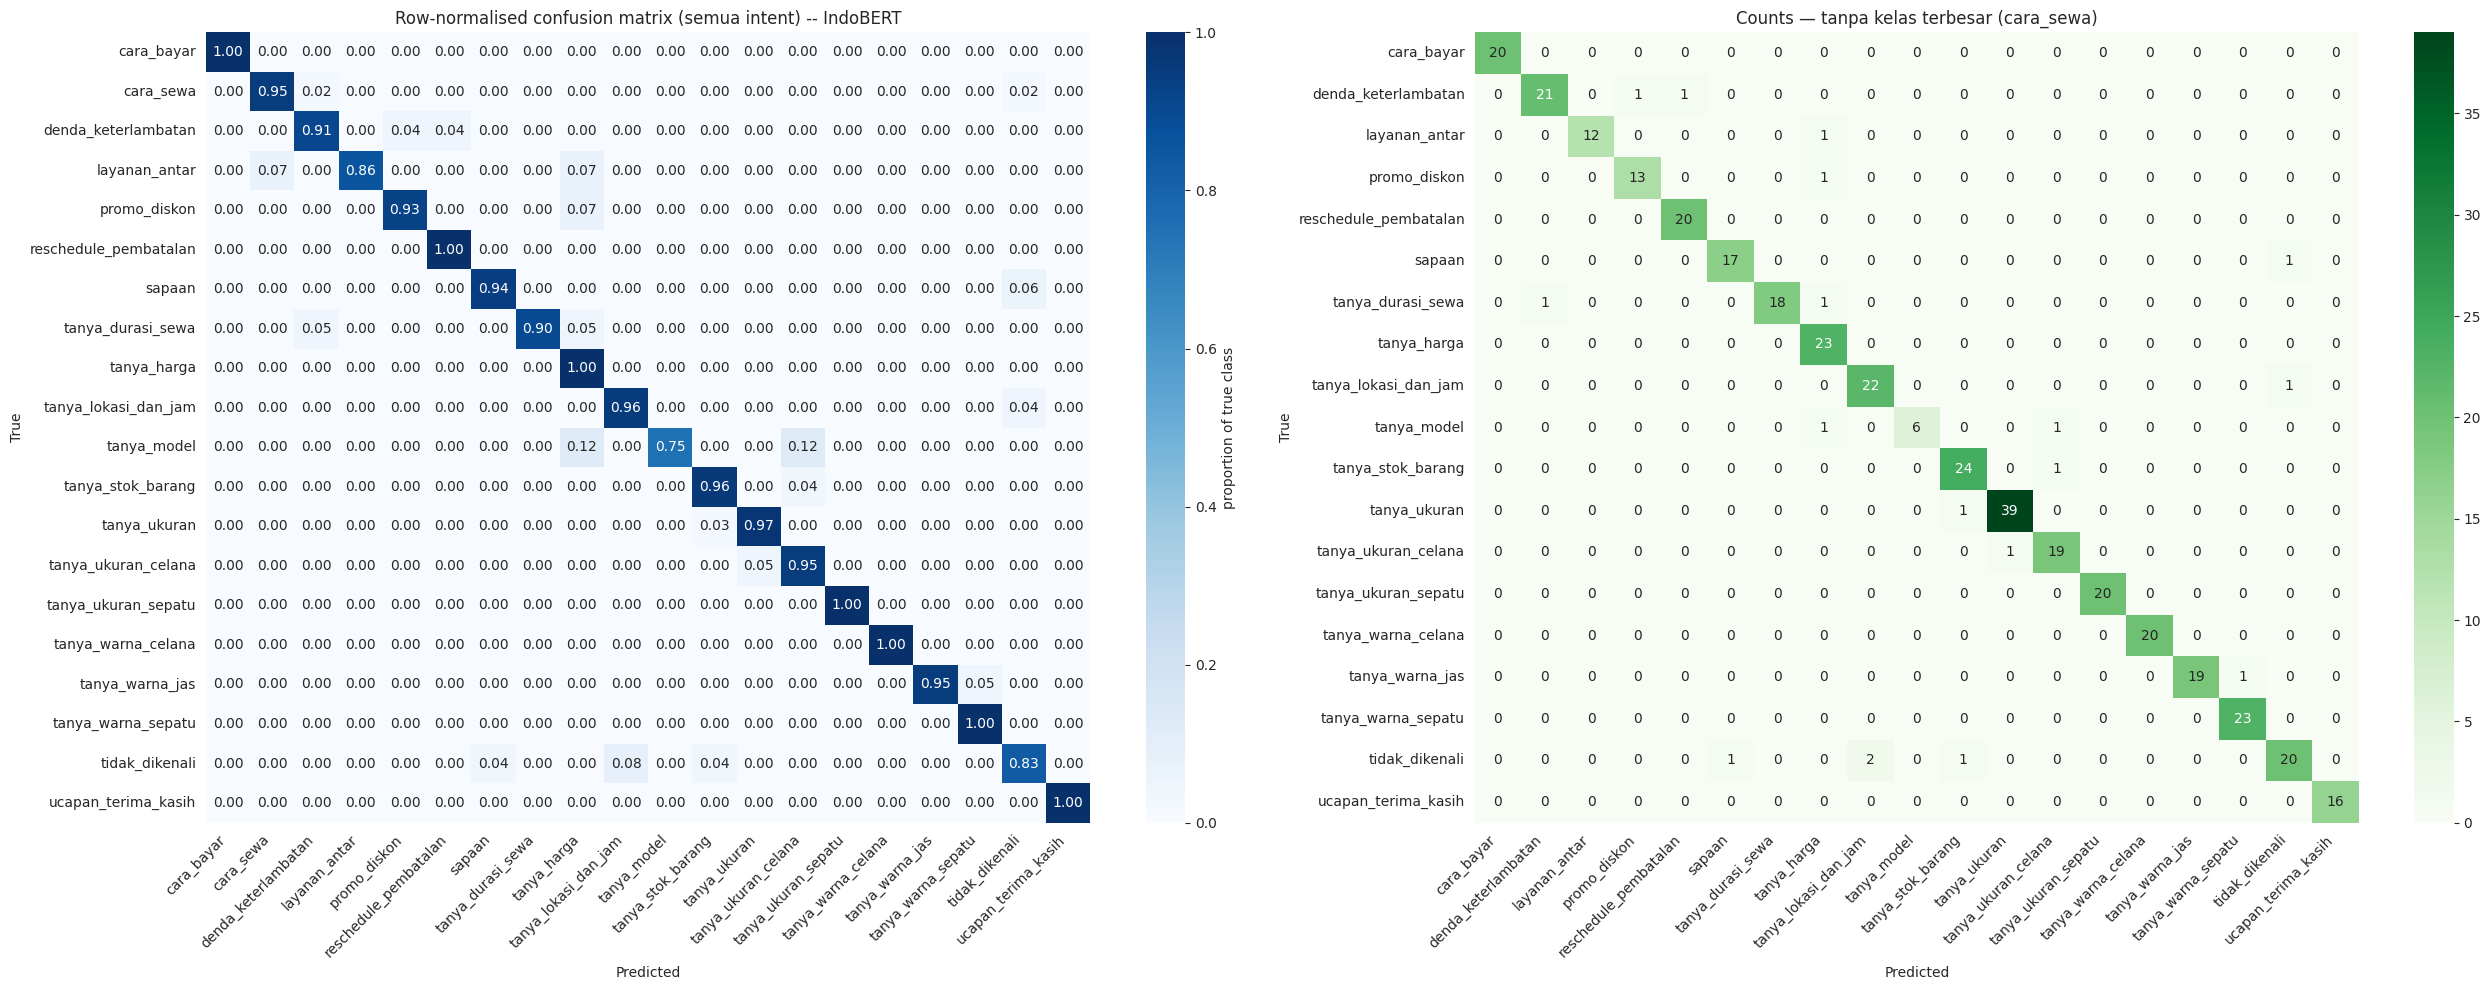

In [56]:
labels_idx = list(range(len(label_encoder.classes_)))
names = label_encoder.classes_
cm = confusion_matrix(y_test, y_pred, labels=labels_idx)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)

biggest = collections.Counter(labels).most_common(1)[0][0]
minority = [i for i, c in enumerate(names) if c != biggest]
cm_min = confusion_matrix(y_test, y_pred, labels=minority)
names_min = [names[i] for i in minority]

fig, axes = plt.subplots(1, 2, figsize=(26, 10))

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
            xticklabels=names, yticklabels=names, ax=axes[0],
            cbar_kws={"label": "proportion of true class"})
axes[0].set_title("Row-normalised confusion matrix (semua intent) -- IndoBERT")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")

sns.heatmap(cm_min, annot=True, fmt="d", cmap="Greens",
            xticklabels=names_min, yticklabels=names_min, ax=axes[1])
axes[1].set_title(f"Counts — tanpa kelas terbesar ({biggest})")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")

for ax in axes:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout(); plt.show()


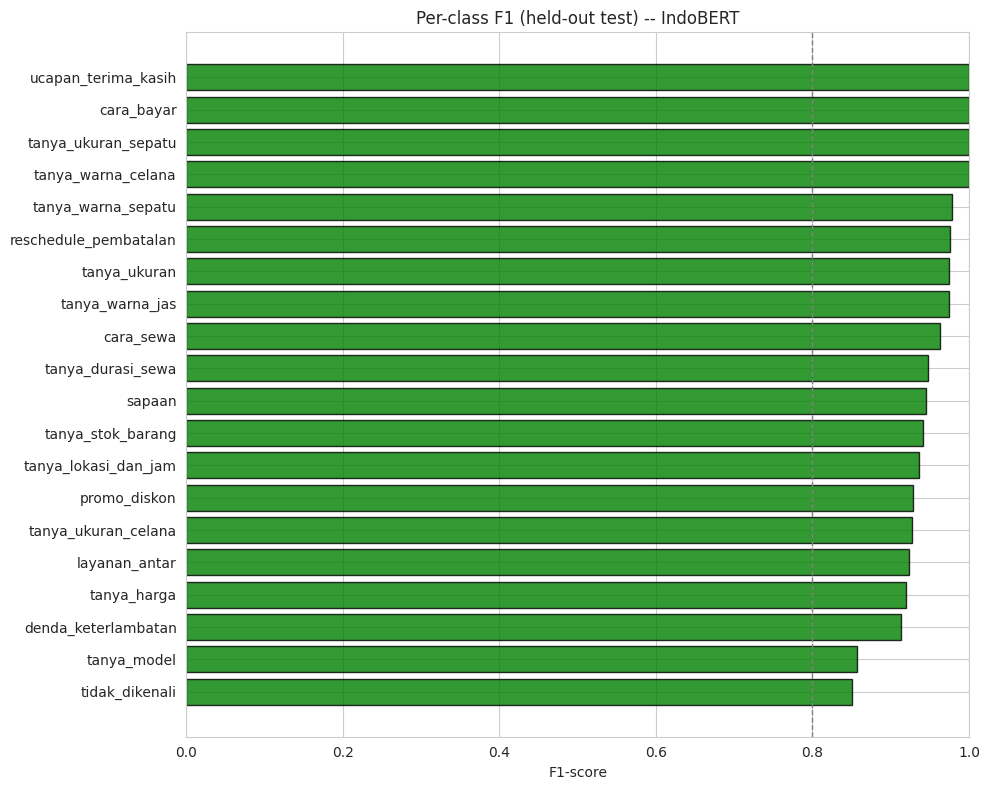

In [57]:
prec, rec, f1, support = precision_recall_fscore_support(
    y_test, y_pred, labels=range(len(label_encoder.classes_)), zero_division=0,
)
order = np.argsort(f1)
plt.figure(figsize=(10, 8))
colors_ = ["green" if v >= 0.8 else "orange" if v >= 0.5 else "red" for v in f1[order]]
plt.barh(range(len(order)), f1[order], color=colors_, alpha=0.8, edgecolor="black")
plt.yticks(range(len(order)), [label_encoder.classes_[i] for i in order])
plt.axvline(0.8, color="gray", ls="--", lw=1)
plt.xlabel("F1-score"); plt.xlim(0, 1.0)
plt.title("Per-class F1 (held-out test) -- IndoBERT")
plt.tight_layout(); plt.show()


## 9. Simpan model + artifak

Model IndoBERT yang sudah di-fine-tune disimpan lengkap (bobot + config + tokenizer)
supaya bisa di-load ulang dengan `AutoModelForSequenceClassification.from_pretrained(...)`
tanpa perlu training ulang.

In [58]:
MODEL_DIR = ROOT / "models"
MODEL_DIR.mkdir(exist_ok=True)
INDOBERT_DIR = MODEL_DIR / "indobert_intent"
INDOBERT_DIR.mkdir(exist_ok=True)

trainer.save_model(str(INDOBERT_DIR))
tokenizer.save_pretrained(str(INDOBERT_DIR))

with open(MODEL_DIR / "label_encoder.pickle", "wb") as f:
    pickle.dump(label_encoder, f)

metadata = {
    "trained_on": str(date.today()),
    "input_dataset": "data/raw/intents_semantic.json",
    "base_model": MODEL_NAME,
    "transformers_version": transformers.__version__,
    "torch_version": torch.__version__,
    "classes": list(label_encoder.classes_),
    "n_classes": N_CLASSES,
    "train_samples_pre_aug": len(p_train),
    "train_samples_post_aug": len(aug_patterns),
    "test_samples": len(p_test),
    "test_accuracy": round(float(acc), 4),
    "test_macro_f1": round(float(macro_f1), 4),
    "max_len": MAX_LEN,
    "random_state": RANDOM_STATE,
}
with open(MODEL_DIR / "metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print("Saved IndoBERT model + tokenizer to", INDOBERT_DIR)
print("Saved label_encoder + metadata to", MODEL_DIR)
print("\nPENTING: kode produksi (jas_chatbot/nlu/pipeline.py, intent_classifier.py) yang tidak")
print("ikut ter-upload di notebook ini kemungkinan masih hardcode load tfidf_vectorizer.pickle +")
print("svm_model.pkl saat inference. Bagian itu perlu diupdate manual di repo kamu supaya load")
print(f"model dari '{INDOBERT_DIR}' via AutoModelForSequenceClassification, bukan SVM lagi.")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved IndoBERT model + tokenizer to /content/models/indobert_intent
Saved label_encoder + metadata to /content/models

PENTING: kode produksi (jas_chatbot/nlu/pipeline.py, intent_classifier.py) yang tidak
ikut ter-upload di notebook ini kemungkinan masih hardcode load tfidf_vectorizer.pickle +
svm_model.pkl saat inference. Bagian itu perlu diupdate manual di repo kamu supaya load
model dari '/content/models/indobert_intent' via AutoModelForSequenceClassification, bukan SVM lagi.


## 10. Helper jawaban (entity extraction + knowledge base lookup)

Sama seperti pipeline sebelumnya -- bagian ini tidak berubah karena tidak terkait embedding/classifier.

In [59]:
import re

ENTITIES_KATALOG_PATH = ROOT / "/content/drive/MyDrive/v4/jas-chatbot/data/knowledge/entities_katalog.json"
with open(ENTITIES_KATALOG_PATH, encoding="utf-8") as f:
    _katalog = json.load(f)

def extract_all_entities(text: str) -> dict:
    text_l = text.lower()
    found = {}
    for warna in _katalog["warna"]:
        if warna.lower() in text_l:
            found["warna"] = warna
            break
    for ukuran in _katalog["ukuran"]:
        if re.search(rf"\b{re.escape(ukuran.lower())}\b", text_l):
            found["ukuran"] = ukuran
            break
    for key in ("model_jas", "model_celana"):
        for model in _katalog.get(key, []):
            if model.lower() in text_l:
                found["model"] = model
                break
        if "model" in found:
            break
    return found

def detect_jenis_barang(text: str) -> str | None:
    text_l = text.lower()
    for jenis in ("jas", "celana", "sepatu"):
        if jenis in text_l:
            return jenis
    return None

def _iter_varian_warna_with_model(produk: dict, model: str = None):
    """Yield (nama_model_atau_None, varian_warna_entry).
    Produk dengan dimensi model (jas, celana) -> nama_model diisi.
    Produk flat/lama (mis. sepatu, belum ada model) -> None."""
    if "varian_model" in produk:
        for vm in produk["varian_model"]:
            if model and model.lower() != vm["model"].lower():
                continue
            for v in vm.get("varian_warna", []):
                yield vm["model"], v
    else:
        for v in produk.get("varian_warna", []):
            yield None, v

def cari_stok(kb: dict, jenis_barang: str, warna: str = None, ukuran: str = None, model: str = None):
    produk = kb.get("produk", {}).get(jenis_barang)
    if not produk:
        return []
    hasil = []
    for m, v in _iter_varian_warna_with_model(produk, model):
        if warna and warna.lower() not in v["warna"].lower():
            continue
        stok_map = v.get("stok_per_ukuran", {})
        if ukuran:
            u = ukuran.upper()
            if u in stok_map:
                hasil.append((m, v["warna"], u, stok_map[u]))
        else:
            for u, jumlah in stok_map.items():
                hasil.append((m, v["warna"], u, jumlah))
    return hasil

INTENT_CONF_THRESHOLD = 0.65

def generate_jawaban(intent: str, confidence: float, teks_asli: str, data: dict, kb: dict) -> str:
    if confidence < INTENT_CONF_THRESHOLD:
        return "Maaf, aku kurang yakin maksudnya apa. Boleh dijelasin lebih detail?"

    if intent == "tanya_lokasi_dan_jam":
        info = kb.get("informasi_toko", {})
        jam = info.get("jam_operasional", "-")
        alamat = info.get("alamat", "-")
        return f"Tokonya buka {jam}. Alamatnya di {alamat}."

    if intent == "tanya_stok_barang":
        entitas = extract_all_entities(teks_asli)
        jenis = detect_jenis_barang(teks_asli)
        if jenis:
            hasil = cari_stok(kb, jenis, entitas.get("warna"), entitas.get("ukuran"), entitas.get("model"))
            if hasil:
                if len(hasil) == 1:
                    model, warna, ukuran, jumlah = hasil[0]
                    label_model = f"model {model}, " if model else ""
                    return f"Stok {jenis} {label_model}warna {warna} ukuran {ukuran} tinggal {jumlah} unit."
                lines = []
                for model, w, u, j in hasil:
                    prefix = f"[{model}] " if model else ""
                    lines.append(f"- {prefix}{w}, ukuran {u}: {j} unit")
                return f"Stok {jenis} yang tersedia:\n" + "\n".join(lines)
        return "Boleh sebutin jenis barang, warna, dan ukurannya biar aku cekin stoknya?"

    return next((i["jawaban_default"] for i in data["intents"] if i["tag"] == intent), None)

## 11. Smoke test (langsung pakai model IndoBERT yang baru difine-tune)

Sel ini self-contained -- gak bergantung ke `NLUPipeline` produksi lama (yang sebelumnya
di-hardcode ke TF-IDF+SVM), supaya bisa langsung dites begitu training selesai.

In [60]:
model.eval()

_VOCAB = set()
for intent in data["intents"]:
    for pattern in intent["patterns"]:
        _VOCAB.update(re.findall(r"\w+", pattern.lower()))

def is_likely_gibberish(text, vocab=_VOCAB, oov_ratio_threshold=0.7):
    tokens = re.findall(r"\w+", text.lower())
    if not tokens:
        return True
    known = sum(1 for t in tokens if t in vocab)
    oov_ratio = 1 - (known / len(tokens))
    return oov_ratio >= oov_ratio_threshold


@torch.no_grad()
def predict_intent(text: str):
    clean = preprocess_for_bert(text)
    enc = tokenizer(clean, truncation=True, padding="max_length",
                     max_length=MAX_LEN, return_tensors="pt").to(DEVICE)
    logits = model(**enc).logits
    proba = torch.softmax(logits, dim=-1)[0].cpu().numpy()
    top = int(np.argmax(proba))
    intent = label_encoder.classes_[top]
    conf = float(proba[top])
    if is_likely_gibberish(text) or conf < INTENT_CONF_THRESHOLD:
        return "tidak_dikenali", conf
    return intent, conf


tests = [
    "halo", "hai", "min pagi", "ada jas ukuran L gak", "celana warna navy ada?",
    "gimana cara sewa nya", "telat kena denda berapa", "lagi ada promo gak min",
    "sepatu ukuran 42 ready?", "asdkjh qweqwe zxcvb",
]
for t in tests:
    intent, conf = predict_intent(t)
    print(f"{t:34} -> {intent:24} ({conf:.2f})")


halo                               -> sapaan                   (1.00)
hai                                -> sapaan                   (1.00)
min pagi                           -> sapaan                   (1.00)
ada jas ukuran L gak               -> tanya_ukuran             (1.00)
celana warna navy ada?             -> tanya_warna_celana       (1.00)
gimana cara sewa nya               -> cara_sewa                (1.00)
telat kena denda berapa            -> denda_keterlambatan      (1.00)
lagi ada promo gak min             -> promo_diskon             (1.00)
sepatu ukuran 42 ready?            -> tanya_ukuran_sepatu      (1.00)
asdkjh qweqwe zxcvb                -> tidak_dikenali           (1.00)


## 12. Chat interaktif (opsional, buat ngetes manual)

In [61]:
while True:
    teks = input("Kamu: ")
    if teks.strip().lower() in ("exit", "keluar", "quit"):
        break

    intent, conf = predict_intent(teks)
    entitas = extract_all_entities(teks)
    ent = ", ".join(f"{k}:{v}" for k, v in entitas.items() if v) or "-"

    jawaban = generate_jawaban(intent, conf, teks, data, kb)
    print(f"Bot [{intent}, conf={conf:.2f}, entity={ent}]: {jawaban}\n")


Kamu: tes
Bot [tidak_dikenali, conf=0.99, entity=-]: Waduh, aku belum nangkep maksudnya nih 😅 Coba tanya soal ukuran, warna, harga, cara sewa, syarat, atau pembayaran ya. Kalau masih bingung, langsung aja chat admin biar dibantu lebih detail.

Kamu: halo
Bot [sapaan, conf=1.00, entity=-]: Haiii selamat datang! 👋 Mau nanya-nanya soal jas, celana, atau sepatu buat disewa? Langsung tembak aja pertanyaannya, aku bantuin 😊

Kamu: hlo
Bot [tidak_dikenali, conf=1.00, entity=-]: Waduh, aku belum nangkep maksudnya nih 😅 Coba tanya soal ukuran, warna, harga, cara sewa, syarat, atau pembayaran ya. Kalau masih bingung, langsung aja chat admin biar dibantu lebih detail.

Kamu: min
Bot [sapaan, conf=1.00, entity=-]: Haiii selamat datang! 👋 Mau nanya-nanya soal jas, celana, atau sepatu buat disewa? Langsung tembak aja pertanyaannya, aku bantuin 😊

Kamu: stok jas
Bot [tanya_stok_barang, conf=1.00, entity=-]: Stok jas yang tersedia:
- [Slim Fit] Hitam, ukuran XS: 5 unit
- [Slim Fit] Hitam, ukuran S: 5 

In [62]:
DRIVE_MODELS_DIR = Path("/content/drive/MyDrive/v4/jas-chatbot/models")
DRIVE_MODELS_DIR.mkdir(parents=True, exist_ok=True)

trainer.save_model(str(DRIVE_MODELS_DIR))
tokenizer.save_pretrained(str(DRIVE_MODELS_DIR))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/v4/jas-chatbot/models/tokenizer_config.json',
 '/content/drive/MyDrive/v4/jas-chatbot/models/tokenizer.json')

In [63]:
import pandas as pd

salah = pd.DataFrame({
    "teks": [preprocess_for_bert(p) for p in p_test],
    "asli": y_test_lbl,
    "prediksi": label_encoder.inverse_transform(y_pred),
})
salah = salah[salah["asli"] != salah["prediksi"]]
pd.set_option("display.max_colwidth", None)
print(f"Jumlah salah: {len(salah)} / {len(p_test)}")
salah.sort_values("asli")

Jumlah salah: 21 / 432


,teks,asli,prediksi
413,abis chat sini terus ngapain lagi min,cara_sewa,tidak_dikenali
355,min kalo saya telat bawa jaminan pas booking gimana,cara_sewa,denda_keterlambatan
375,"kalo barang balik lebih cepat dari jadwal, ada potongan gak",denda_keterlambatan,promo_diskon
0,ganti rugi kalau rusak berapa?,denda_keterlambatan,reschedule_pembatalan
189,"saya mau opsi ambil sendiri aja, itu dipotong biaya gak min",layanan_antar,tanya_harga
146,kalau gak ada orang di rumah gimana,layanan_antar,cara_sewa
37,harga promo nya berlaku sampai kapan min,promo_diskon,tanya_harga
11,kak mau confirm ini bener toko sewa jas kan,sapaan,tidak_dikenali
159,"min kalo hari terakhir sewa jatuh di hari libur, gimana pengembaliannya",tanya_durasi_sewa,denda_keterlambatan
300,min sewa singkat kaya setengah hari itu harganya beda jauh gak sama full day,tanya_durasi_sewa,tanya_harga
